#CONNECT DRIVE

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#MAMBA

import & setup

In [2]:
import pandas as pd
import numpy as np
import time
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

model

In [3]:
class MambaBlock(nn.Module):
    def __init__(self, d_model, expand=2, d_conv=4, dropout=0.1):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.d_inner = expand * d_model
        self.in_proj = nn.Linear(d_model, self.d_inner * 2)
        self.conv1d = nn.Conv1d(
            self.d_inner,
            self.d_inner,
            kernel_size=d_conv,
            padding=d_conv - 1,
            groups=self.d_inner
        )
        self.out_proj = nn.Linear(self.d_inner, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.norm(x)
        xz = self.in_proj(x)
        x_inner, z = xz.chunk(2, dim=-1)

        x_inner = x_inner.transpose(1, 2)
        x_inner = self.conv1d(x_inner)[:, :, :x.shape[1]]
        x_inner = x_inner.transpose(1, 2)

        x_inner = F.silu(x_inner)
        z = torch.sigmoid(z)

        out = x_inner * z
        out = self.dropout(out)
        return residual + self.out_proj(out)

class WindMamba(nn.Module):
    def __init__(self, input_size, d_model=64, num_layers=2):
        super().__init__()
        self.embed = nn.Linear(input_size, d_model)

        self.layers = nn.ModuleList([
            MambaBlock(d_model) for _ in range(num_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        self.fc = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )

    def forward(self, x):
        x = self.embed(x)
        for layer in self.layers:
            x = layer(x)
        x = self.norm(x)
        return self.fc(x[:, -1, :])

def train_mamba(file_path, station_name):
    print(f"\nXử lý trạm: {station_name}")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Đang chạy trên thiết bị: {device}")

    if not os.path.exists(file_path):
        print(f"Lỗi: Không tìm thấy file {file_path}")
        return

    df = pd.read_csv(file_path) # đọc và setup data
    df['time'] = pd.to_datetime(df['time'])
    df.set_index('time', inplace=True)
    df = df.dropna()

    n = len(df)
    train_end = int(n * 0.7)

    X_df = df.drop(columns=['wind_speed'])
    Y_df = df[['wind_speed']]

    scaler_X = MinMaxScaler()
    scaler_Y = MinMaxScaler()

    scaler_X.fit(X_df.iloc[:train_end])
    scaler_Y.fit(Y_df.iloc[:train_end])

    X_scaled = scaler_X.transform(X_df)
    Y_scaled = scaler_Y.transform(Y_df)

    seq_len = 12
    X_list, Y_list = [], []

    for i in range(len(X_scaled) - seq_len - 10):
        X_list.append(X_scaled[i:i+seq_len])
        y_30  = Y_scaled[i + seq_len + 1][0]
        y_60  = Y_scaled[i + seq_len + 3][0]
        y_120 = Y_scaled[i + seq_len + 7][0]
        Y_list.append([y_30, y_60, y_120])

    X_np = np.array(X_list, dtype=np.float32)
    Y_np = np.array(Y_list, dtype=np.float32)

    n_w = len(X_np)
    w_train = int(n_w * 0.7)
    w_val = int(n_w * 0.85)

    X_train = torch.tensor(X_np[:w_train])
    Y_train = torch.tensor(Y_np[:w_train])
    X_val = torch.tensor(X_np[w_train:w_val])
    Y_val = torch.tensor(Y_np[w_train:w_val])
    X_test = torch.tensor(X_np[w_val:])
    Y_test = torch.tensor(Y_np[w_val:])

    train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val, Y_val), batch_size=64, shuffle=False)

    model = WindMamba(X_train.shape[2]).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)
    criterion = nn.MSELoss()

    best_loss = float('inf')
    patience = 10
    counter = 0

    train_losses, val_losses, epoch_times = [], [], []
    total_train_start = time.time()

    print("\nBắt đầu quá trình huấn luyện...")
    for epoch in range(50):
        epoch_start = time.time()
        model.train()
        train_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                val_loss += criterion(model(xb), yb).item()

        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), f"/content/{station_name}_best_mamba.pt")
            best_epoch_msg = " (New Best)"
        else:
            counter += 1
            best_epoch_msg = ""

        if (epoch + 1) % 5 == 0 or best_epoch_msg != "":
            print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f} | Time: {epoch_time:.2f}s{best_epoch_msg}")

        if counter >= patience:
            print(f"Early stopping kích hoạt tại Epoch {epoch+1}!")
            break

    total_train_time = time.time() - total_train_start
    avg_epoch_time = np.mean(epoch_times)
    print("\nSố liệu chi phí tài nguyên")
    print(f"Tổng thời gian huấn luyện : {total_train_time:.2f} s")
    print(f"Thời gian trung bình/epoch: {avg_epoch_time:.2f} s")

    model.load_state_dict(torch.load(f"/content/{station_name}_best_mamba.pt"))
    model.cpu()
    model.eval()
    sample_input_cpu = X_test[0:1].cpu()

    with torch.no_grad():
        for _ in range(10): _ = model(sample_input_cpu)

    latencies = []
    with torch.no_grad():
        for _ in range(100):
            start_infer = time.time()
            _ = model(sample_input_cpu)
            latencies.append((time.time() - start_infer) * 1000)

    avg_latency = np.mean(latencies)
    print(f"Độ trễ suy luận (CPU Latency): {avg_latency:.4f} ms/mẫu")

    model.to(device)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb in DataLoader(X_test, batch_size=256):
            preds.extend(model(xb.to(device)).cpu().numpy())

    y_pred = scaler_Y.inverse_transform(np.array(preds))
    y_true = scaler_Y.inverse_transform(Y_test.numpy())

    print("\nResult test")
    horizons = ["30min", "60min", "120min"]
    for i, h in enumerate(horizons):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])
        print(f"Horizon {h:6s}: RMSE = {rmse:.4f} | MAE = {mae:.4f} | R2 = {r2:.4f}")

    overall_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\nGlobal RMSE: {overall_rmse:.4f}")

    # biểu đồ
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, label='Train Loss', color='blue', linewidth=1.5)
    plt.plot(val_losses, label='Validation Loss', color='orange', linewidth=1.5)
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title(f"Loss Curve (Mamba) - {station_name}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    plot_steps = 200
    horizons_labels = ["30 Phút", "60 Phút", "120 Phút"]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    fig.suptitle(f"Mamba Forecast vs Actual - {station_name}", fontsize=14, fontweight='bold')

    for i in range(3):
        axes[i].plot(y_true[:plot_steps, i], label="Thực tế (Actual)", color='black', linewidth=1.5)
        axes[i].plot(y_pred[:plot_steps, i], label="Dự báo (Predicted)", color='red', linestyle='--', linewidth=1.5)
        axes[i].set_ylabel("Wind Speed (m/s)")
        axes[i].set_title(f"Horizon: {horizons_labels[i]}")
        axes[i].legend(loc="upper right")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    axes[2].set_xlabel("Time Steps (15-min intervals)")
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Mamba Regression Fit - {station_name}", fontsize=14, fontweight='bold')

    for i in range(3):
        axes[i].scatter(y_true[:, i], y_pred[:, i], alpha=0.3, color='purple', s=10)
        min_val = min(y_true[:, i].min(), y_pred[:, i].min())
        max_val = max(y_true[:, i].max(), y_pred[:, i].max())
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)

        axes[i].set_title(f"{horizons_labels[i]} (R2: {r2_score(y_true[:, i], y_pred[:, i]):.3f})")
        axes[i].set_xlabel("Actual Wind Speed (m/s)")
        if i == 0: axes[i].set_ylabel("Predicted Wind Speed (m/s)")
        axes[i].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

run


Xử lý trạm: Tram_A_DatLien
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00126 | Val Loss: 0.00058 | Time: 8.96s (New Best)
Epoch 02 | Train Loss: 0.00058 | Val Loss: 0.00056 | Time: 7.95s (New Best)
Epoch 03 | Train Loss: 0.00055 | Val Loss: 0.00055 | Time: 6.78s (New Best)
Epoch 05 | Train Loss: 0.00051 | Val Loss: 0.00053 | Time: 6.30s (New Best)
Epoch 07 | Train Loss: 0.00049 | Val Loss: 0.00053 | Time: 6.12s (New Best)
Epoch 09 | Train Loss: 0.00047 | Val Loss: 0.00051 | Time: 6.53s (New Best)
Epoch 10 | Train Loss: 0.00046 | Val Loss: 0.00051 | Time: 7.53s
Epoch 15 | Train Loss: 0.00039 | Val Loss: 0.00055 | Time: 6.82s
Epoch 16 | Train Loss: 0.00039 | Val Loss: 0.00051 | Time: 7.85s (New Best)
Epoch 17 | Train Loss: 0.00038 | Val Loss: 0.00050 | Time: 6.30s (New Best)
Epoch 18 | Train Loss: 0.00038 | Val Loss: 0.00049 | Time: 7.52s (New Best)
Epoch 20 | Train Loss: 0.00037 | Val Loss: 0.00052 | Time: 7.39s
Epoch 25 | Train Loss: 0.00033

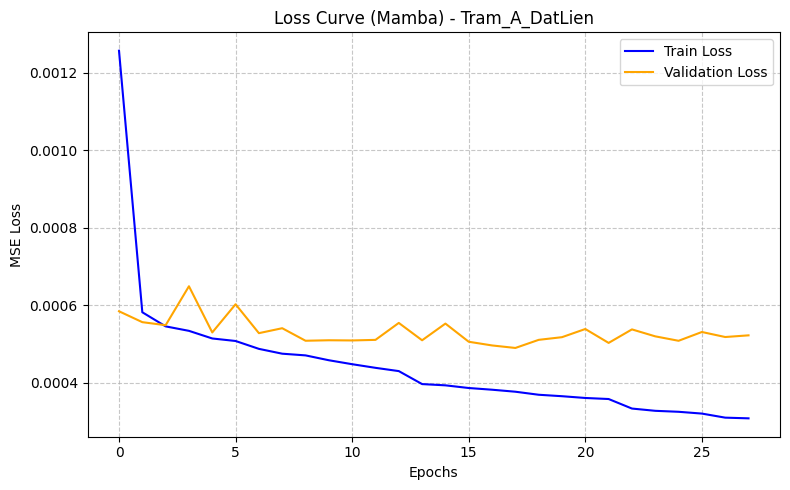

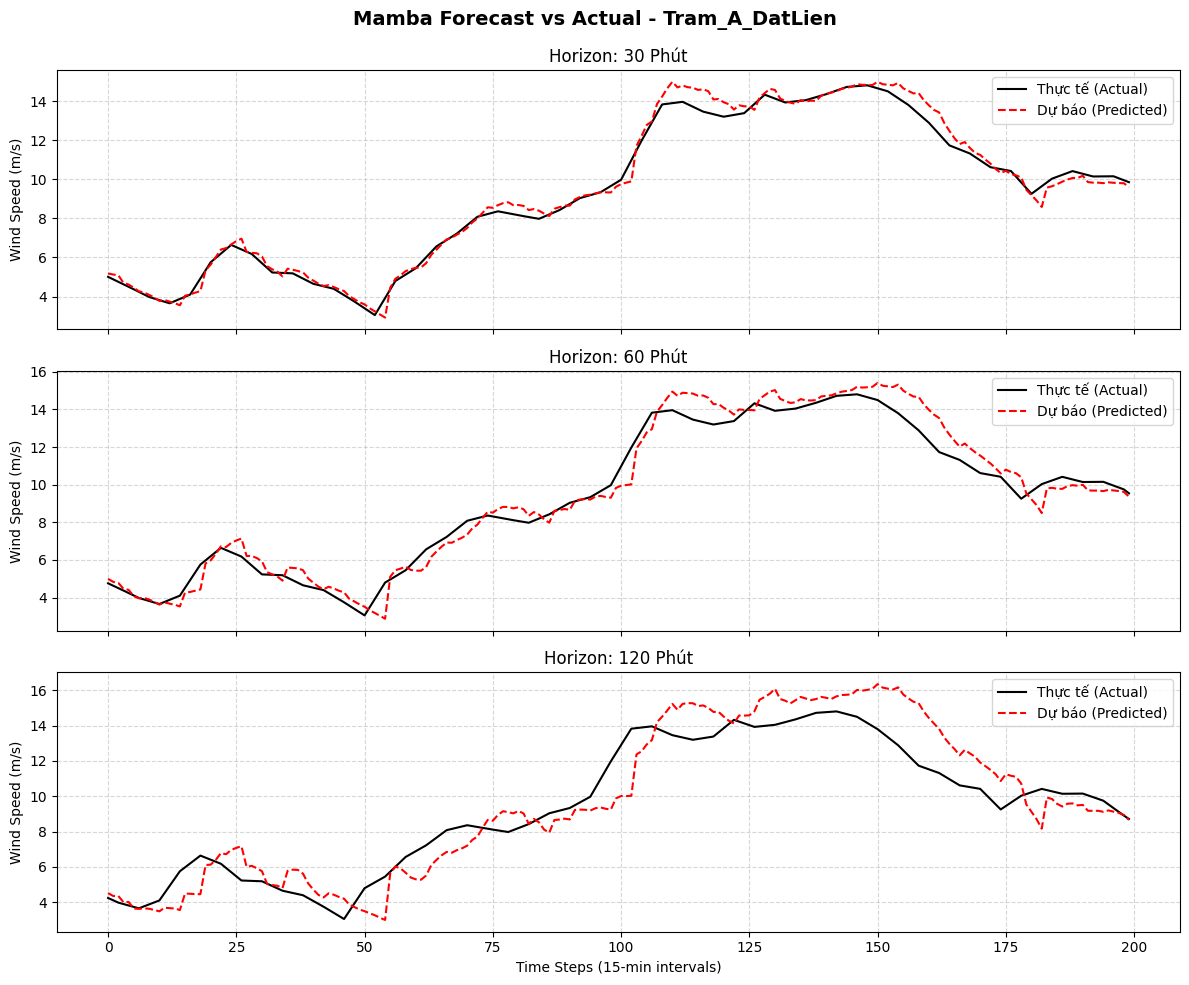

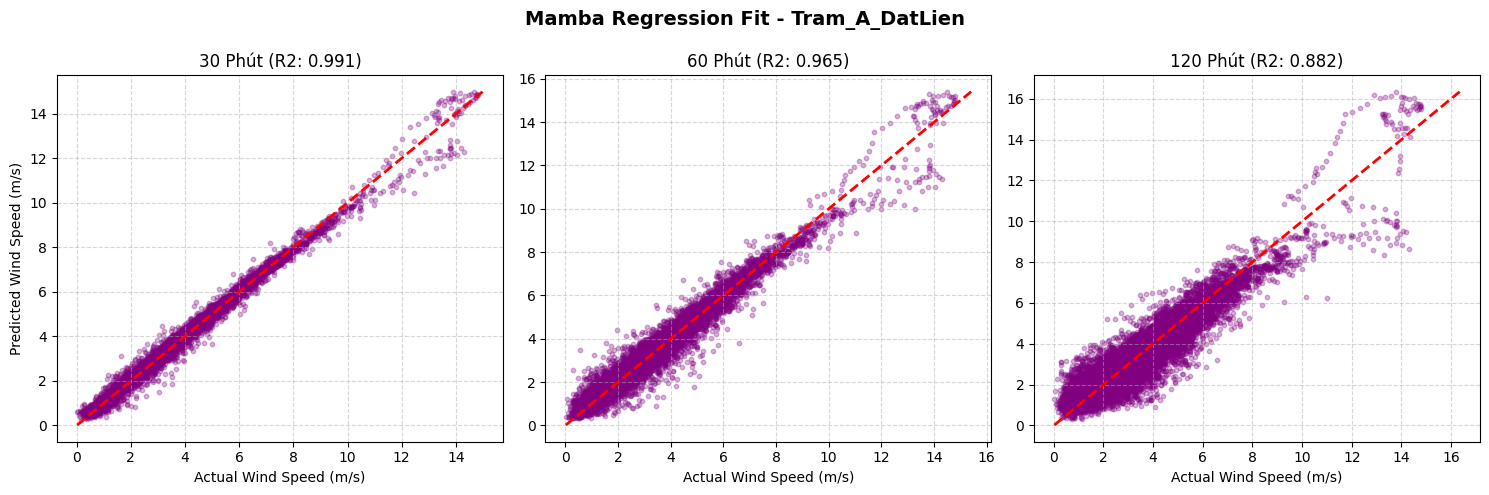


Xử lý trạm: Tram_B_VenBien
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00197 | Val Loss: 0.00058 | Time: 7.06s (New Best)
Epoch 02 | Train Loss: 0.00065 | Val Loss: 0.00053 | Time: 7.75s (New Best)
Epoch 03 | Train Loss: 0.00060 | Val Loss: 0.00051 | Time: 6.81s (New Best)
Epoch 05 | Train Loss: 0.00055 | Val Loss: 0.00048 | Time: 6.41s (New Best)
Epoch 07 | Train Loss: 0.00052 | Val Loss: 0.00047 | Time: 6.34s (New Best)
Epoch 08 | Train Loss: 0.00051 | Val Loss: 0.00046 | Time: 7.33s (New Best)
Epoch 10 | Train Loss: 0.00049 | Val Loss: 0.00047 | Time: 7.20s
Epoch 11 | Train Loss: 0.00048 | Val Loss: 0.00043 | Time: 6.46s (New Best)
Epoch 14 | Train Loss: 0.00046 | Val Loss: 0.00043 | Time: 7.51s (New Best)
Epoch 15 | Train Loss: 0.00045 | Val Loss: 0.00043 | Time: 6.74s
Epoch 20 | Train Loss: 0.00039 | Val Loss: 0.00044 | Time: 7.41s
Epoch 21 | Train Loss: 0.00039 | Val Loss: 0.00042 | Time: 6.20s (New Best)
Epoch 25 | Train Loss: 0.00038

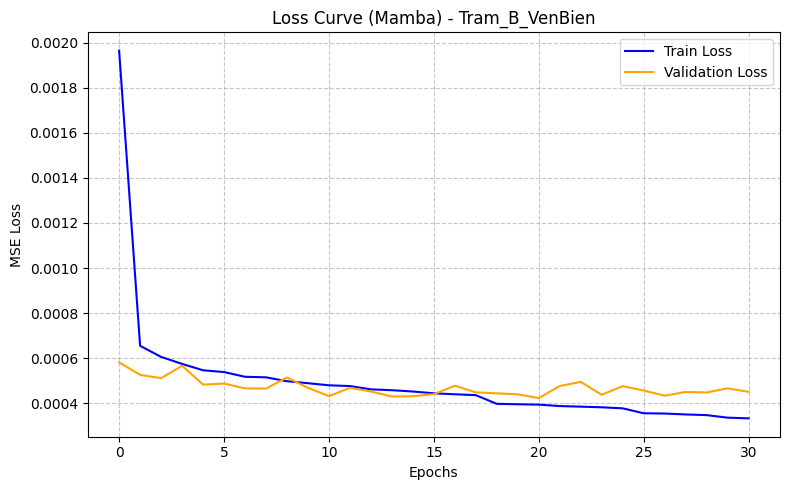

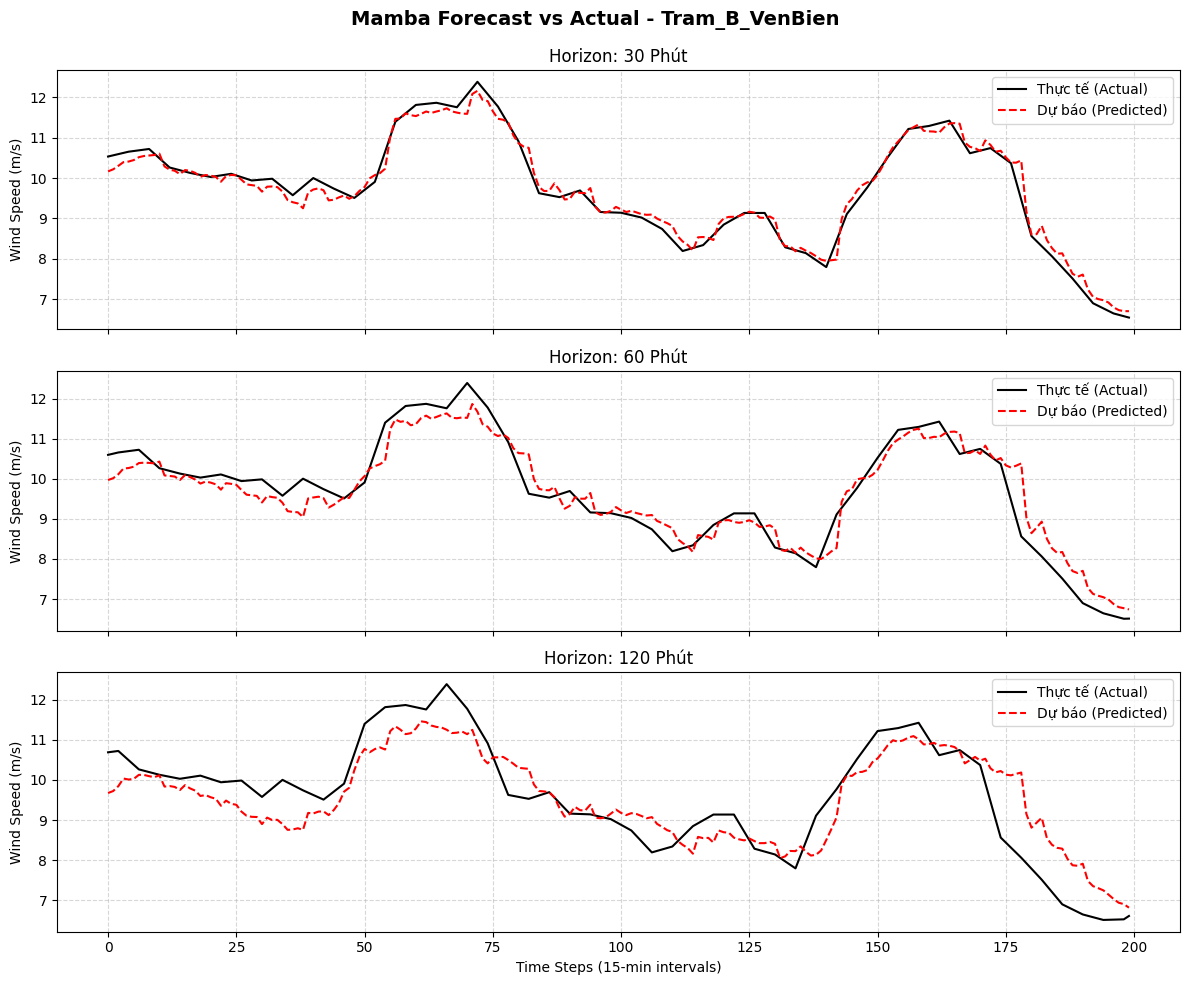

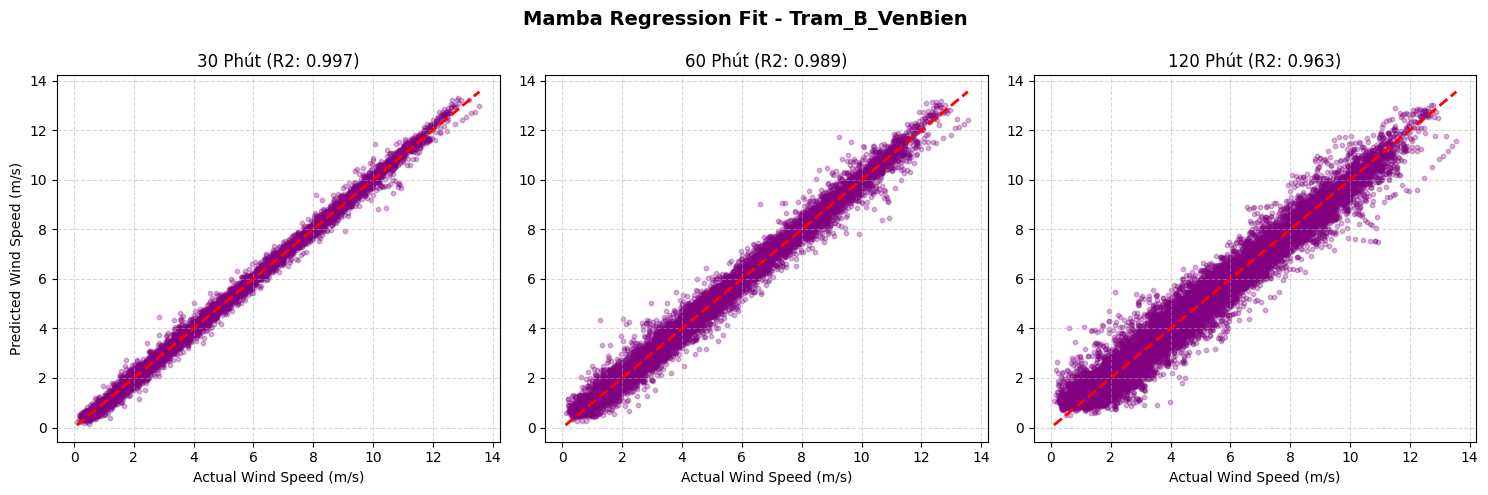


Xử lý trạm: Tram_C_DoiNui
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00271 | Val Loss: 0.00173 | Time: 6.74s (New Best)
Epoch 02 | Train Loss: 0.00111 | Val Loss: 0.00108 | Time: 6.46s (New Best)
Epoch 03 | Train Loss: 0.00103 | Val Loss: 0.00105 | Time: 7.01s (New Best)
Epoch 04 | Train Loss: 0.00099 | Val Loss: 0.00097 | Time: 6.35s (New Best)
Epoch 05 | Train Loss: 0.00096 | Val Loss: 0.00101 | Time: 7.40s
Epoch 07 | Train Loss: 0.00089 | Val Loss: 0.00096 | Time: 7.13s (New Best)
Epoch 09 | Train Loss: 0.00086 | Val Loss: 0.00094 | Time: 7.01s (New Best)
Epoch 10 | Train Loss: 0.00083 | Val Loss: 0.00099 | Time: 6.08s
Epoch 11 | Train Loss: 0.00081 | Val Loss: 0.00093 | Time: 7.40s (New Best)
Epoch 12 | Train Loss: 0.00080 | Val Loss: 0.00089 | Time: 6.34s (New Best)
Epoch 13 | Train Loss: 0.00077 | Val Loss: 0.00086 | Time: 7.58s (New Best)
Epoch 15 | Train Loss: 0.00075 | Val Loss: 0.00088 | Time: 7.22s
Epoch 20 | Train Loss: 0.00063 

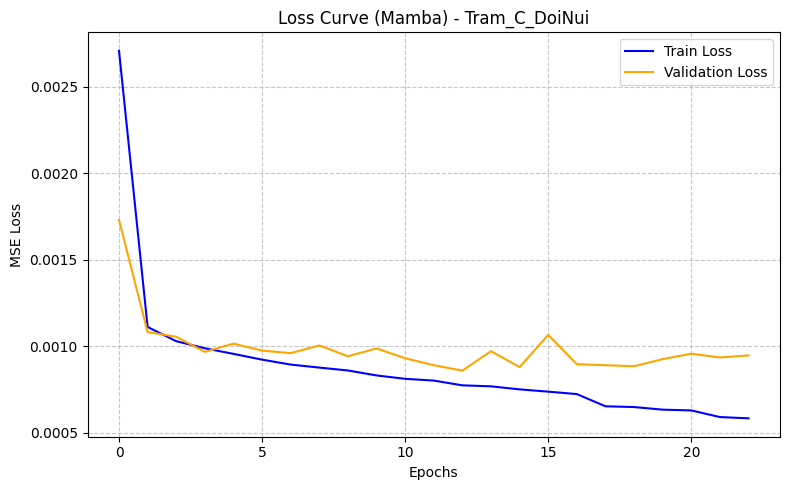

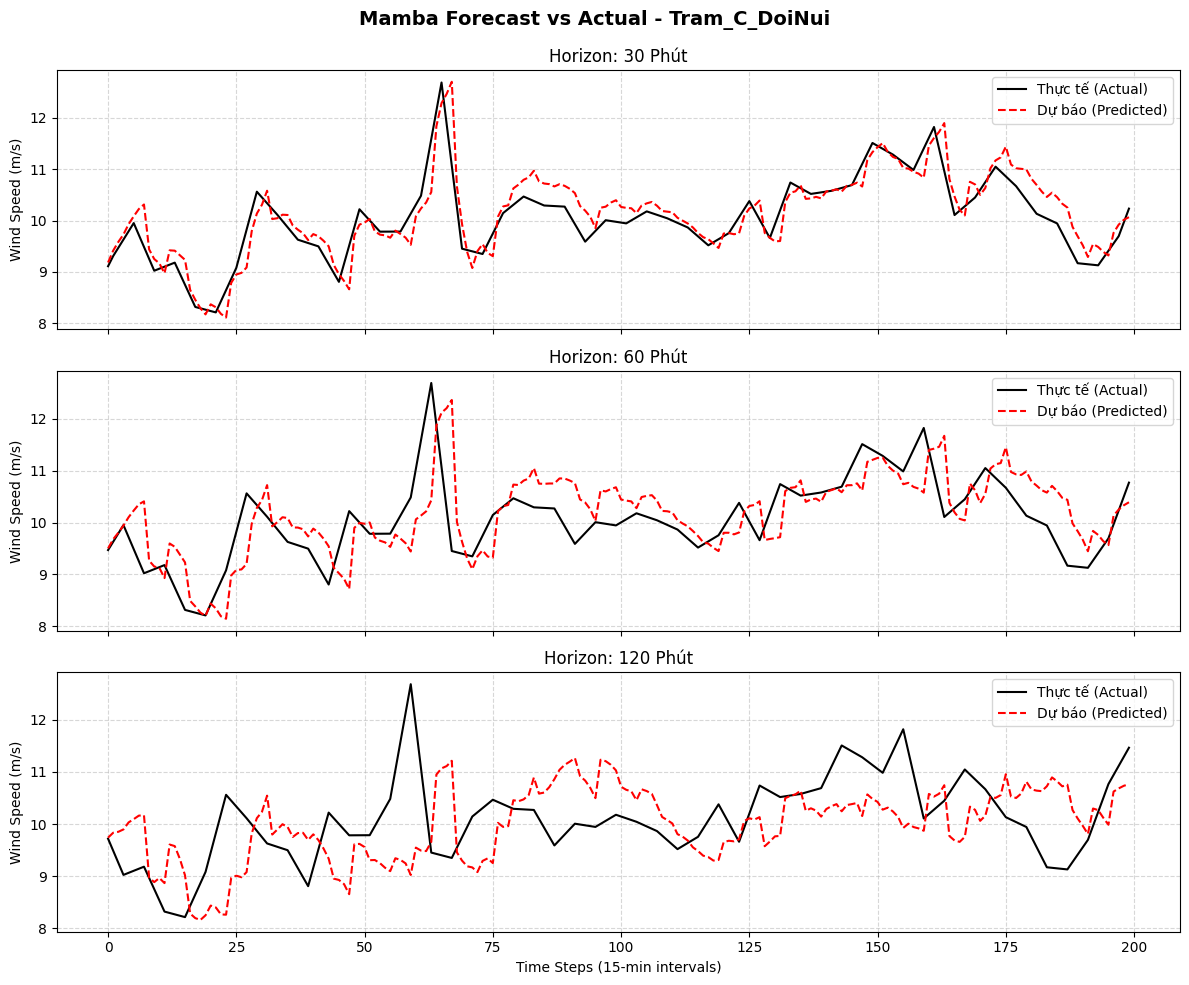

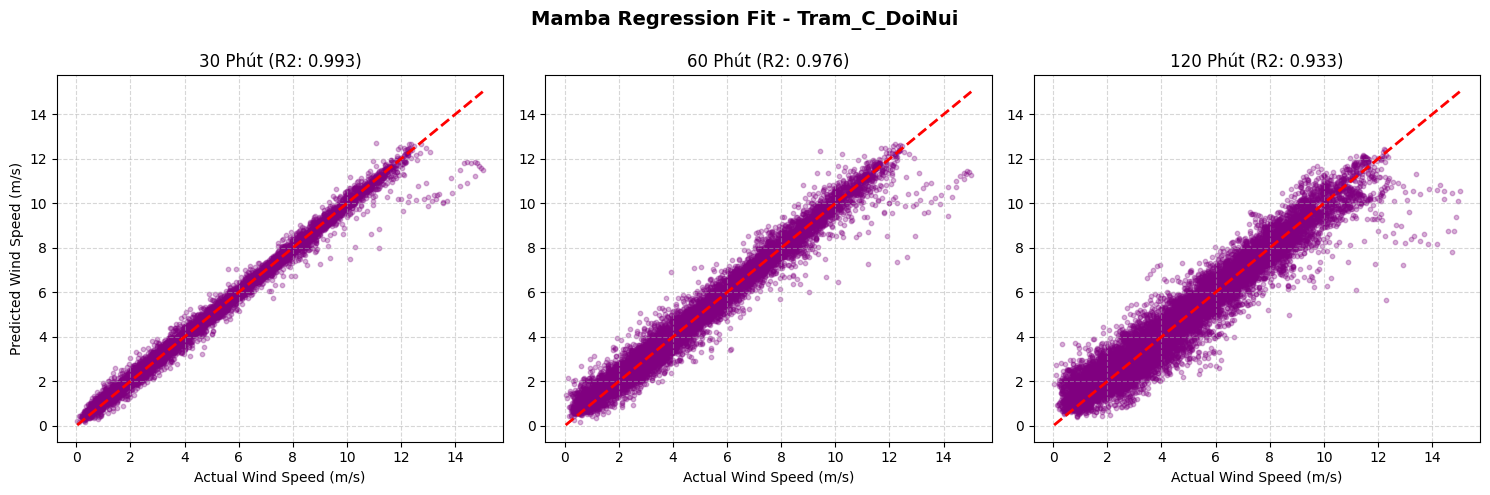


Xử lý trạm: Tram_D_NgoaiKhoi
Đang chạy trên thiết bị: cuda

Bắt đầu quá trình huấn luyện...
Epoch 01 | Train Loss: 0.00126 | Val Loss: 0.00039 | Time: 6.20s (New Best)
Epoch 02 | Train Loss: 0.00034 | Val Loss: 0.00034 | Time: 7.18s (New Best)
Epoch 04 | Train Loss: 0.00030 | Val Loss: 0.00031 | Time: 7.06s (New Best)
Epoch 05 | Train Loss: 0.00029 | Val Loss: 0.00029 | Time: 6.02s (New Best)
Epoch 09 | Train Loss: 0.00026 | Val Loss: 0.00029 | Time: 6.30s (New Best)
Epoch 10 | Train Loss: 0.00025 | Val Loss: 0.00031 | Time: 6.51s
Epoch 11 | Train Loss: 0.00025 | Val Loss: 0.00028 | Time: 6.49s (New Best)
Epoch 14 | Train Loss: 0.00023 | Val Loss: 0.00028 | Time: 6.05s (New Best)
Epoch 15 | Train Loss: 0.00022 | Val Loss: 0.00027 | Time: 6.94s (New Best)
Epoch 20 | Train Loss: 0.00019 | Val Loss: 0.00026 | Time: 6.56s (New Best)
Epoch 21 | Train Loss: 0.00019 | Val Loss: 0.00025 | Time: 6.99s (New Best)
Epoch 25 | Train Loss: 0.00018 | Val Loss: 0.00025 | Time: 6.64s
Epoch 27 | Train 

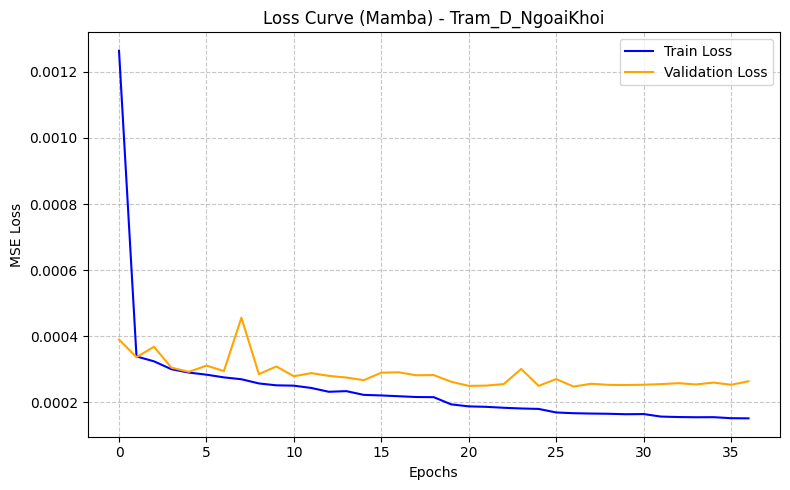

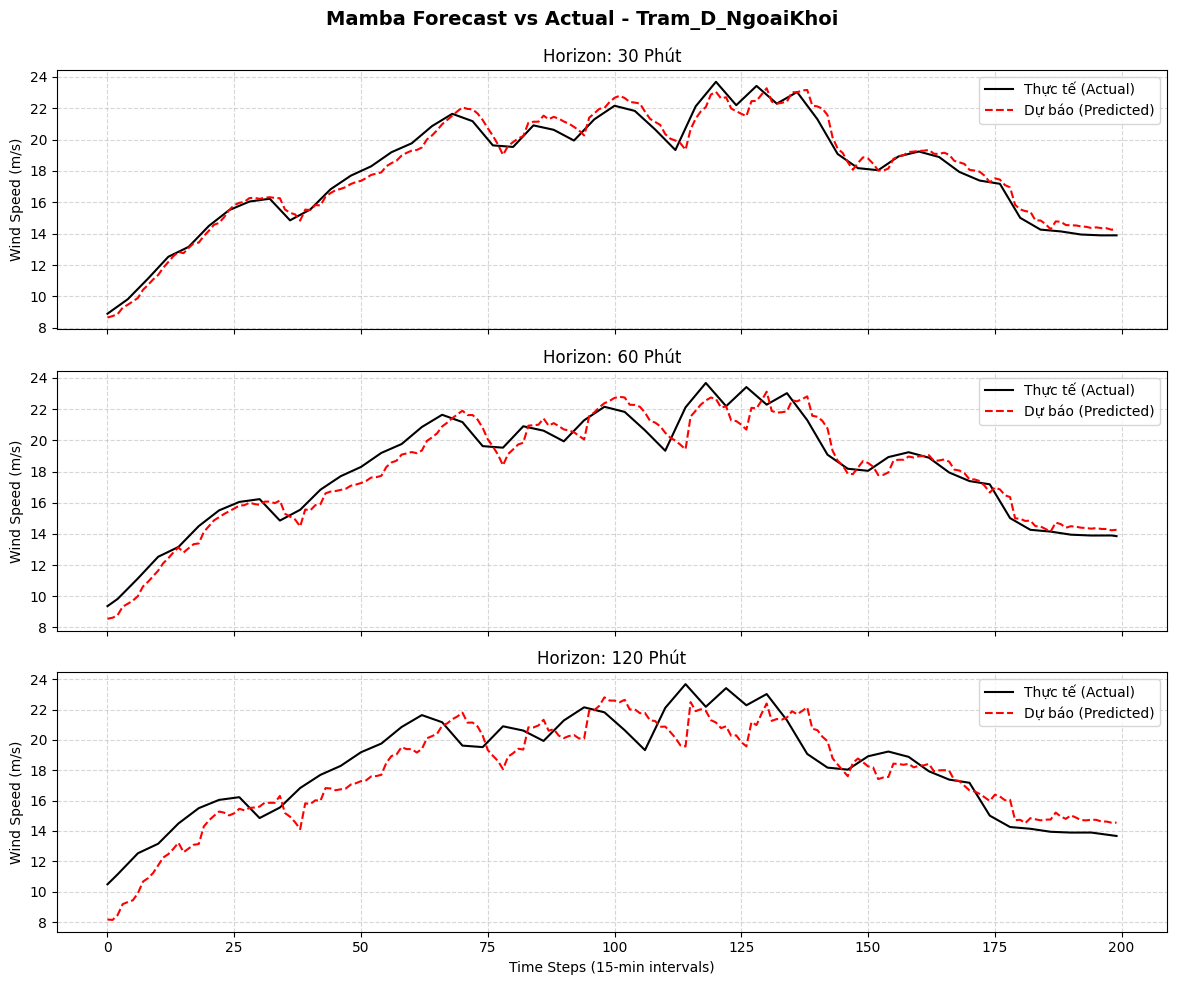

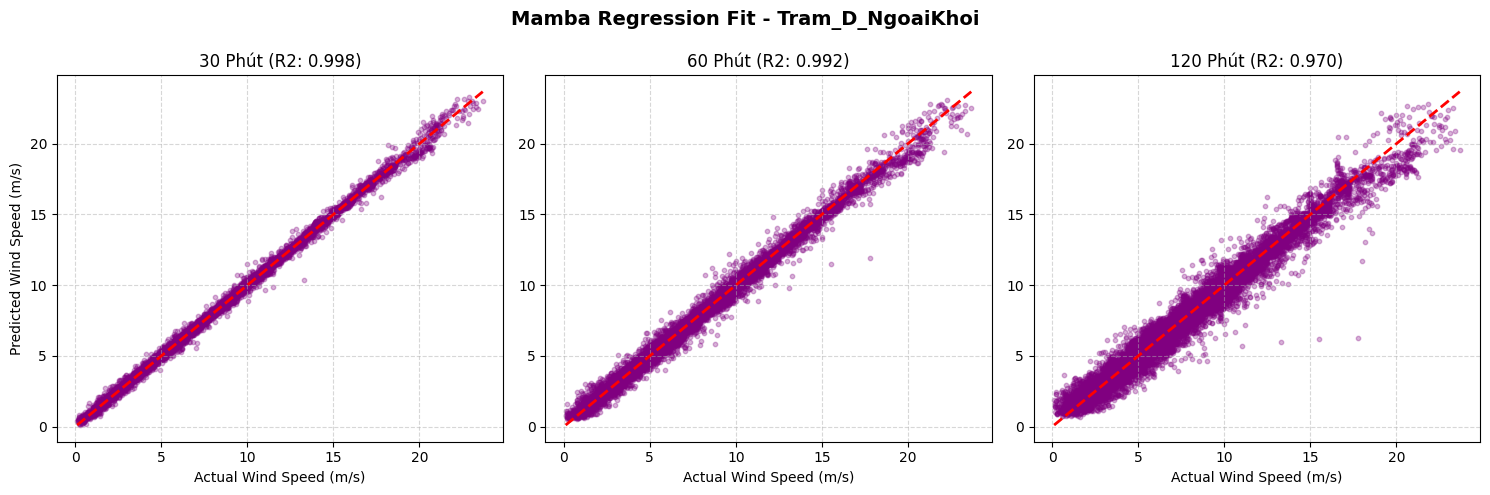

In [4]:
stations = [
    "Tram_A_DatLien",
    "Tram_B_VenBien",
    "Tram_C_DoiNui",
    "Tram_D_NgoaiKhoi"
]

base_path = "/content/drive/MyDrive/WIND_FORECAST_DATA/"

for station in stations:
    path = f"{base_path}{station}_FINAL_MASTER.csv"
    train_mamba(path, station)